In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse
import math  
import sklearn.metrics 
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Resumen

1. Crear la matriz de usuarios/películas
2. Solucionar problema escasez de datos
3. Crear la matriz de similitud
4. KN-Neighbours
5. Mejor K y distancia para KN-Neighbours

## 1. Crear la matriz usuarios/películas

In [2]:
df = pd.read_csv("BBDD_100K/ratings.csv")
df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [3]:
indice=list(df['userId'].unique())
columnas=list(df['movieId'].unique())
indice=sorted(indice)
columnas=sorted(columnas)
 
escasez=pd.pivot_table(data=df,values='rating',index='userId',columns='movieId')
escasez.head(10)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,3.0,5.0,4.0,4.0,3.0,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Solucionar problema escasez de datos

Para solucionar la escasez de datos voy a probar normalizando todos los datos de la tabla

1. Primero voy a restar la calificación promedio de cada usuario para centrarla alrededor de 0 \
    2.1 Esto es útil porque facilita las comparaciones entre usuarios y/o ítems, eliminando posibles sesgos debido a diferentes escalas de calificaciones o preferencias personales de los usuarios. 
2. Finalmente voy a convertir los NaN a 0

In [4]:
def escasez_de_datos_promedio(matriz_escasez):
    valoraciones_promedio = matriz_escasez.mean(axis = 1)
    restar_promedio = matriz_escasez.sub(valoraciones_promedio , axis = 0)
    restar_promedio = restar_promedio.fillna(0) #Rellenamos valores sobrantes por 0
    return restar_promedio

In [5]:
usuario_pelicula = escasez_de_datos_promedio(escasez)
usuario_pelicula.head(10)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.366379,0.000000,-0.366379,0.000000,0.000000,-0.366379,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.363636,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.000000,0.506369,1.506369,-0.493631,1.506369,0.506369,0.506369,-0.493631,0.0,-0.493631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1.269737,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.000000,0.425532,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-1.574468,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Crear la matriz de similitud

1. Primero separaré al usuario para predecir sus calificaciones, en nuestro caso lo haremos con el usuario número 3
2. Después eliminaré la película que quiero predecir (en este caso y gracias al EDA utilizaré la película con mas valoraciones, la cual es Forrest Gump, con el id nº356)
3. Finalmente crearé el conjunto de usuarios que vieron esa película en específico 

In [6]:
id_usuario = 3
usuario_objetivo = usuario_pelicula.iloc[[id_usuario]]
print("Usuario Objetivo:")
usuario_objetivo.head()

Usuario Objetivo:


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
id_pelicula = 356
pelicula_objetivo = usuario_pelicula.drop( id_pelicula , axis =1)
print("Película Objetivo:")
pelicula_objetivo.head()

Película Objetivo:


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.366379,0.0,-0.366379,0.0,0.0,-0.366379,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.363636,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Crear bbdd con los usuarios que han visto esa peli

In [8]:
usuarios_que_vieron_la_pelicula_con_nulls = usuario_pelicula[356]  # Selecciono todas las filas respecto a la película en cuestión
usuarios_que_vieron_la_pelicula = usuario_pelicula[usuarios_que_vieron_la_pelicula_con_nulls != 0] # Seleccionamos solo las filas con valores diferentes a 0, de entre los que vieron esa película
#Muestra de los usuarios que vieron la película


print("Shape de usuarios_que_vieron_la_pelicula_con_nulls:", usuarios_que_vieron_la_pelicula_con_nulls.shape)
print("Shape de usuarios_que_vieron_la_pelicula:", usuarios_que_vieron_la_pelicula.shape)
usuarios_que_vieron_la_pelicula[356].head(20)

Shape de usuarios_que_vieron_la_pelicula_con_nulls: (610,)
Shape de usuarios_que_vieron_la_pelicula: (329, 9724)


userId
1    -0.366379
6     1.506369
7     1.769737
8    -0.574468
10    0.221429
11    1.218750
14    0.604167
15    1.551852
16   -0.224490
17    0.790476
18    0.767928
19   -0.607397
21    1.239278
22    2.428571
24    0.850000
26   -0.238095
27    1.451852
28    0.979825
29    0.358025
33    1.211538
Name: 356, dtype: float64

## 4. K-NNeighbours

 algoritmo de KNN lo utilizaré con la libreria sklearn, la cual nos proporciona el uso de diferentes distancias, tales como: minkowski,manhattan , euclídea, jaccard, chebyshev, coseno... Lo que haré en esta sección es aplicar KNN y comparar las diferentes distáncias para evaluar cual es la mejor

 1. Distancia Minkowski
 2. Distancia Manhattan
 3. Distancia Eucídeana
 4. Distancia Jaccard
 5. Distancia Chebyshev
 6. Distancia Coseno

 Recordar que el resultado obtenido por parte del KNN está normalizado a rango [-1,1], por tanto hay que reescalarlo para poder ver cual sería en realidad

In [9]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial import distance_matrix
from scipy.spatial.distance import euclidean, pdist, squareform
from sklearn.model_selection import GridSearchCV, cross_val_score

Para cuadrar las dimensiones

In [10]:
usuarios_que_vieron_la_pelicula_con_nulls = usuarios_que_vieron_la_pelicula_con_nulls.loc[usuarios_que_vieron_la_pelicula.index]

In [11]:
min_rating = 0.5
max_rating = 5.0

def reescalar(res_distancia):
    prediccion_reescalada = ((res_distancia + 1) / 2) * (max_rating - min_rating) + min_rating
    print("Prediccion reescalada: " +str(prediccion_reescalada))

Similitud mediante distancia de minkowski

La p de la distancia Minkowski la hemos de poner a 3 o superior, a mayor cambio mayores oscilaciones tendrá la predicción, debido al énfasis que se le pone al cambio brusco de distancias. Esto lo hago ya que si no pongo p=3, por defecto se utiliza p=2, que es la que usa la distancia euclideana y por tanto darían exactamente lo mismo

In [12]:
usuario_minkowski = KNeighborsRegressor(metric='minkowski',p=3, n_neighbors=20)
usuario_minkowski.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls)
prediccion_usuario_minkoswki = usuario_minkowski.predict(usuario_objetivo)
print("Prediccion normalizada: " +str(prediccion_usuario_minkoswki))
reescalar(prediccion_usuario_minkoswki)

Prediccion normalizada: [0.43444098]
Prediccion reescalada: [3.72749222]


Similitud mediante distancia de Manhattan

In [13]:
usuario_manhattan = KNeighborsRegressor(metric='manhattan', n_neighbors=20)
usuario_manhattan.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls)
prediccion_usuario_manhattan = usuario_manhattan.predict(usuario_objetivo)
print("Prediccion normalizada: " +str(prediccion_usuario_manhattan))
reescalar(prediccion_usuario_manhattan)


Prediccion normalizada: [0.2882469]
Prediccion reescalada: [3.39855553]


Similitud mediante distancia de Euclideana

In [14]:
usuario_euclideana = KNeighborsRegressor(metric='euclidean', n_neighbors=20)
usuario_euclideana.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls)
prediccion_usuario_euclideana = usuario_euclideana.predict(usuario_objetivo)
print("Prediccion normalizada: " +str(prediccion_usuario_euclideana))
reescalar(prediccion_usuario_euclideana)

Prediccion normalizada: [0.35993502]
Prediccion reescalada: [3.55985379]


Similitud mediante distancia de Jaccard

In [15]:
usuario_jaccard = KNeighborsRegressor(metric='jaccard', n_neighbors=20)
usuario_jaccard.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls)
prediccion_usuario_jaccard = usuario_jaccard.predict(usuario_objetivo)
print("Prediccion normalizada: " +str(prediccion_usuario_jaccard))
reescalar(prediccion_usuario_jaccard)

Prediccion normalizada: [0.39211862]
Prediccion reescalada: [3.63226689]


Similitud mediante distancia de Chabyshev

In [16]:
usuario_chebyshev = KNeighborsRegressor(metric='chebyshev', n_neighbors=20)
usuario_chebyshev.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls)
prediccion_usuario_chebyshev = usuario_chebyshev.predict(usuario_objetivo)
print("Prediccion normalizada: " +str(prediccion_usuario_chebyshev))
reescalar(prediccion_usuario_chebyshev)

Prediccion normalizada: [0.41651415]
Prediccion reescalada: [3.68715685]


Similitud mediante distancia de Coseno

In [17]:
usuario_coseno = KNeighborsRegressor(metric='cosine', n_neighbors=20)
usuario_coseno.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls)
prediccion_usuario_coseno = usuario_coseno.predict(usuario_objetivo)
print("Prediccion normalizada: " +str(prediccion_usuario_coseno))
reescalar(prediccion_usuario_coseno)

Prediccion normalizada: [0.59663854]
Prediccion reescalada: [4.09243671]


Como nos interesa saber cual es la mejor k posible, voy a unificar en diversas funciones todo lo hecho hasta el momento, automatizando los resultados y de esta forma poder evaluar cualquier usuario y cualquier película siempre que queramos

In [18]:
def peliculas_del_usuario(usuario, matriz_escasez):
    # Filtramos las películas que no tienen valor NaN para el usuario
    usuario_data = matriz_escasez.iloc[usuario].dropna()

    # Obtenemos las películas y sus valoraciones
    lista_peliculas = usuario_data.index.tolist()  # Películas votadas
    valoraciones_originales = usuario_data.values.tolist()  # Valoraciones correspondientes

    # print("ID's de películas votadas por el usuario: " + str(lista_peliculas[:10]) + "... (total: " + str(len(lista_peliculas)) + ")")
    # print("Valoraciones de las películas votadas por el usuario: " + str(valoraciones_originales[:10]) + "... (total: " + str(len(valoraciones_originales)) + ")")
    
    return lista_peliculas, valoraciones_originales


In [19]:
def peliculas_con_minimo_vecinos(lista_peliculas_usuario, valoraciones_peliculas, usuario_pelicula, vecinos_min):
    # Filtramos solo las películas con al menos 'vecinos_min' valoraciones distintas de 0
    peliculas_filtradas = []
    valoraciones_filtradas = []
    
    for i, pelicula in enumerate(lista_peliculas_usuario):
        # Asegurarse de que 'pelicula' es el identificador correcto que corresponde a las columnas de usuario_pelicula
        if pelicula not in usuario_pelicula.columns:
            print(f"Película {pelicula} no encontrada en las columnas.")
            continue
        
        # Seleccionamos los usuarios que vieron la película, es decir, aquellos con valoraciones != 0
        usuarios_que_vieron_la_pelicula = usuario_pelicula[usuario_pelicula[pelicula].notna() & (usuario_pelicula[pelicula] != 0)][pelicula]
        
        # Si el número de usuarios que vieron la película es mayor o igual a 'vecinos_min', la añadimos a la lista
        if len(usuarios_que_vieron_la_pelicula) >= vecinos_min:
            peliculas_filtradas.append(pelicula)
            valoraciones_filtradas.append(valoraciones_peliculas[i])  # Añadimos la valoración correspondiente

    return peliculas_filtradas, valoraciones_filtradas


In [20]:
def reescalar_prediccion(prediccion, min_rating=0.5, max_rating=5.0):
    # Escalar la predicción a un rango deseado (por ejemplo, entre 0.5 y 5.0)
    prediccion_reescalada = ((prediccion + 1) / 2) * (max_rating - min_rating) + min_rating
    # Asegurarse de que la predicción quede dentro del rango [min_rating, max_rating]
    return np.clip(prediccion_reescalada, min_rating, max_rating)

def similitud_distancias(lista_peliculas_usuario, usuario, distancia_escogida, vecinos, minkowski=False):
    lista_similitud = []
    usuario_objetivo = usuario_pelicula.iloc[[usuario]]  # Datos del usuario objetivo
    
    # Recorrer las películas votadas por el usuario
    for pelicula in lista_peliculas_usuario:
        # Seleccionamos las valoraciones de los usuarios que han visto la película y que no tienen valoraciones nulas o 0
        usuarios_que_vieron_la_pelicula_con_nulls = usuario_pelicula[pelicula]
        usuarios_que_vieron_la_pelicula = usuario_pelicula[usuarios_que_vieron_la_pelicula_con_nulls.notna() & (usuarios_que_vieron_la_pelicula_con_nulls != 0)]
        usuarios_que_vieron_la_pelicula_con_nulls = usuarios_que_vieron_la_pelicula_con_nulls.loc[usuarios_que_vieron_la_pelicula.index]

        # Definir el modelo KNN
        knn = KNeighborsRegressor(metric=distancia_escogida, p=3 if minkowski else None, n_neighbors=vecinos)
        
        # Ajustar el modelo
        knn.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls)
        
        # Predecir para el usuario objetivo
        prediccion_usuario = knn.predict(usuario_objetivo)
        
        # Reescalar la predicción para que esté dentro del rango adecuado
        prediccion_reescalada = reescalar_prediccion(prediccion_usuario[0])
        
        lista_similitud.append(prediccion_reescalada)  # Añadir la predicción reescalada a la lista de similitudes

    return lista_similitud

In [21]:
def mejor_cantidad_de_vecinos(usuario, lista_peliculas, valoraciones_peliculas, min_vecinos, distancia_escogida, minkowski=False):
    mejor_k = None
    mejor_error = float('inf')
    resultados_vecinos = []

    for k in range(1, min_vecinos):
        # Obtenemos las predicciones utilizando similitud_distancias
        similitud = similitud_distancias(lista_peliculas, usuario, distancia_escogida, k, minkowski)
        
        # Reescalado de las predicciones (si es necesario
        
        # Calculamos el error con las valoraciones originales no normalizadas
        evaluacion = sklearn.metrics.mean_squared_error(valoraciones_peliculas, similitud)
        resultados_vecinos.append(evaluacion)
        
        print("Cuando usamos k= " + str(k) + " obtenemos " + str(evaluacion))
        
        if evaluacion < mejor_error:
            mejor_k = k
            mejor_error = evaluacion
    
    print("Mejor resultado obtenido con la distancia " + distancia_escogida + " es K = " + str(mejor_k))

    # Graficamos el MSE para diferentes valores de k
    plt.plot(range(1, len(resultados_vecinos) + 1), resultados_vecinos)
    plt.xlabel('Número de vecinos (k)')
    plt.ylabel('Error (MSE)')
    plt.title(f'Evolución del MSE según k (Distancia: {distancia_escogida})')
    plt.show()

    return mejor_k,resultados_vecinos


Como podemos ver a continuación, hay películas que las han votado menos de K personas, si queremos buscar la K óptima para poder trabajar con KNN tendremos que filtrar estas películas que tienen menos de K valoraciones.

Una vez encontrada esta mejor K, lo que se puede hacer es eliminar todas las peliculas con menos de esa cantidad de valoraciones del conjunto de datos principal, de esta manera siempre tendremos la mejor K disponible para el uso, si no se eliminan estos datos de la base de datos principal lo que ocurrirá es que deberemos usar siempre k=1, ya que siempre habrá alguna película con solo 1 valoración.

Puesto que lo que quiero con este algoritmo es predecir películas no me sirve demasiado que existan películas que solo ha visto 1 persona, necesito mas datos para poder trabajar con estas, por tanto es conveniente reducir el tamaño de los datos a películas con menos valoraciones de la K óptima obtenida.

Importante --> KNN no funcionará si queremos usar mas vecinos de los que existen

In [28]:
usuario=3
min_vecinos = 20
# lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario,escasez)
lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario,escasez)
lista_peliculas = lista_peliculas[0:50] #limitaremos a 50 las peliculas
valoraciones_peliculas = valoraciones_peliculas[0:50] #limitaremos a 50 las peliculas


Procesando usuario: 3
Matriz de escasez antes de filtrar: (610, 9724)


In [29]:
# Obtener identificadores de películas
lista_peliculas, valoraciones_peliculas = peliculas_con_minimo_vecinos(lista_peliculas_usuario=lista_peliculas, valoraciones_peliculas=valoraciones_peliculas, usuario_pelicula=usuario_pelicula, vecinos_min=min_vecinos)
similitudes = similitud_distancias(lista_peliculas_usuario=lista_peliculas, usuario=usuario, distancia_escogida='euclidean', vecinos=min_vecinos)
print(similitudes)


[2.7361165585255804, 3.8355928925054386, 2.5930278990223754, 3.9576511382916517, 1.4804513814959668, 3.448483186668768, 2.1708605123576854, 2.397324777825212, 3.9819084552520403, 3.760710160721983, 1.9436412502832732, 1.1277246482956285, 1.862890763853352, 2.337878224818124, 2.229641672482871, 2.046480909446079, 3.2227280989085245, 1.9823061208600878, 2.461691974115601, 3.272147357386212, 3.3043394423774557, 0.9606908020671456]


Ahora lo que voy a hacer es calcular la mejor K en todas las distancias posibles, la distancia que de menor error y con la K mas grande será la mas indicada para utilizarse

In [24]:
def evaluar_todas_las_distancias(usuario, lista_peliculas, valoraciones_peliculas, min_vecinos):
    distancias = ['euclidean', 'manhattan', 'cosine', 'jaccard', 'chebyshev', 'minkowski']
    errores_por_distancia = {}
    
    for distancia in distancias:
        print(f"\nEvaluando con la distancia: {distancia}")
        _, errores = mejor_cantidad_de_vecinos(usuario, lista_peliculas, valoraciones_peliculas, min_vecinos, distancia, minkowski=(distancia=='minkowski'))
        errores_por_distancia[distancia] = errores
        
    return errores_por_distancia

def graficar_errores_por_distancia(errores_por_distancia, min_vecinos):
    plt.figure(figsize=(10, 6))
    
    for distancia, errores in errores_por_distancia.items():
        plt.plot(range(1, min_vecinos), errores, label=f'{distancia}')
    
    plt.xlabel('Número de vecinos (k)')
    plt.ylabel('Error (MSE)')
    plt.title('Comparación de MSE por diferentes distancias y número de vecinos (k)')
    plt.legend()
    plt.show()


Evaluando con la distancia: euclidean
Cuando usamos k= 1 obtenemos 0.8867187499999997
Cuando usamos k= 2 obtenemos 0.5117269566249724
Cuando usamos k= 3 obtenemos 0.6710291912400155
Cuando usamos k= 4 obtenemos 0.6974958826514364
Cuando usamos k= 5 obtenemos 0.816345462204565
Cuando usamos k= 6 obtenemos 0.7637016338802135
Cuando usamos k= 7 obtenemos 0.7674435238049668
Cuando usamos k= 8 obtenemos 0.9651538649851876
Cuando usamos k= 9 obtenemos 1.1045906941696706
Cuando usamos k= 10 obtenemos 1.094587907270252
Cuando usamos k= 11 obtenemos 1.1179178265909213
Cuando usamos k= 12 obtenemos 1.1465973816254038
Cuando usamos k= 13 obtenemos 1.216066213086944
Cuando usamos k= 14 obtenemos 1.253588602943296
Cuando usamos k= 15 obtenemos 1.286583282003612
Cuando usamos k= 16 obtenemos 1.3088965621067676
Cuando usamos k= 17 obtenemos 1.316814932738236
Cuando usamos k= 18 obtenemos 1.3186547632083263
Cuando usamos k= 19 obtenemos 1.2651889042855866
Mejor resultado obtenido con la distancia euc

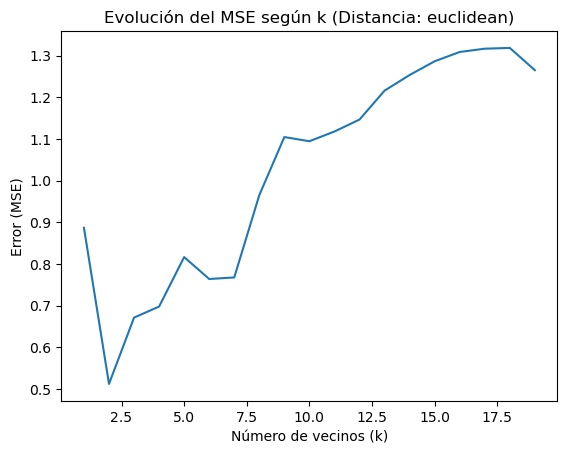


Evaluando con la distancia: manhattan
Cuando usamos k= 1 obtenemos 0.8867187499999997
Cuando usamos k= 2 obtenemos 0.44954242282376977
Cuando usamos k= 3 obtenemos 0.5723792156003833
Cuando usamos k= 4 obtenemos 0.9199691391697085
Cuando usamos k= 5 obtenemos 0.9196464894072204
Cuando usamos k= 6 obtenemos 0.863920668928386
Cuando usamos k= 7 obtenemos 0.8915164081754865
Cuando usamos k= 8 obtenemos 1.0133441759329638
Cuando usamos k= 9 obtenemos 1.196046106108246
Cuando usamos k= 10 obtenemos 1.2105269645223817
Cuando usamos k= 11 obtenemos 1.1609925774548946
Cuando usamos k= 12 obtenemos 1.2005534459441507
Cuando usamos k= 13 obtenemos 1.2377805031210305
Cuando usamos k= 14 obtenemos 1.3162845116812925
Cuando usamos k= 15 obtenemos 1.3083929173558757
Cuando usamos k= 16 obtenemos 1.3176693756887827
Cuando usamos k= 17 obtenemos 1.3920215559309546
Cuando usamos k= 18 obtenemos 1.385087534511309
Cuando usamos k= 19 obtenemos 1.361920867295614
Mejor resultado obtenido con la distancia 

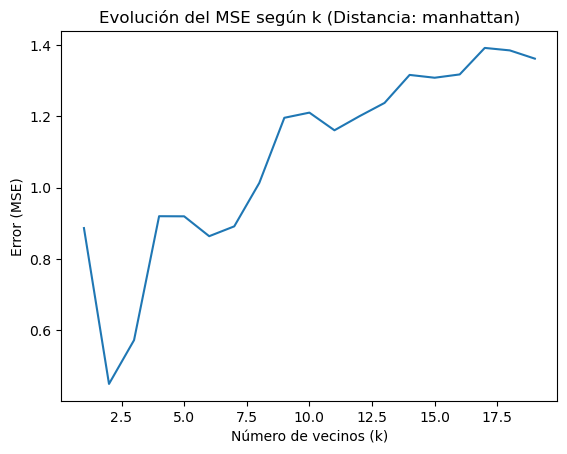


Evaluando con la distancia: cosine
Cuando usamos k= 1 obtenemos 0.8867187499999997
Cuando usamos k= 2 obtenemos 1.305503950894611
Cuando usamos k= 3 obtenemos 1.0010137363960405
Cuando usamos k= 4 obtenemos 0.9482328531474983
Cuando usamos k= 5 obtenemos 0.931106331188843
Cuando usamos k= 6 obtenemos 1.0032886484197916
Cuando usamos k= 7 obtenemos 1.0924990549609983
Cuando usamos k= 8 obtenemos 1.221696795047199
Cuando usamos k= 9 obtenemos 1.2138262557116617
Cuando usamos k= 10 obtenemos 1.2098754534489888
Cuando usamos k= 11 obtenemos 1.096031871201792
Cuando usamos k= 12 obtenemos 1.1019415928635568
Cuando usamos k= 13 obtenemos 0.9756243399595299
Cuando usamos k= 14 obtenemos 0.8630030809228901
Cuando usamos k= 15 obtenemos 0.9289166429091559
Cuando usamos k= 16 obtenemos 0.987379032951595
Cuando usamos k= 17 obtenemos 0.9179146884550642
Cuando usamos k= 18 obtenemos 0.8929170745852979
Cuando usamos k= 19 obtenemos 0.8963118992867778
Mejor resultado obtenido con la distancia cosin

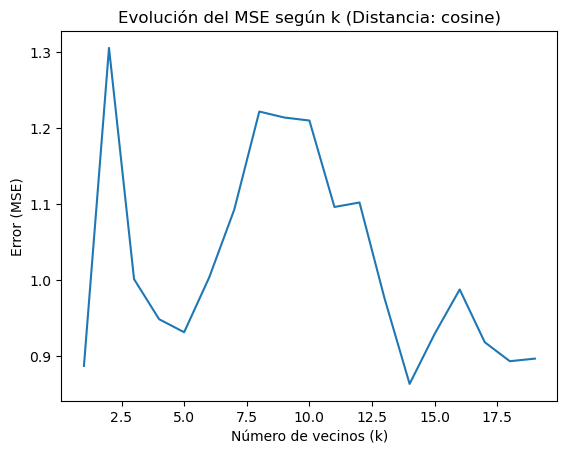


Evaluando con la distancia: jaccard
Cuando usamos k= 1 obtenemos 0.8867187499999997
Cuando usamos k= 2 obtenemos 0.7917503901367166
Cuando usamos k= 3 obtenemos 1.2996378902269343
Cuando usamos k= 4 obtenemos 1.6839887772172704
Cuando usamos k= 5 obtenemos 1.7757302375981778
Cuando usamos k= 6 obtenemos 1.8837771112076958
Cuando usamos k= 7 obtenemos 1.924025609492879
Cuando usamos k= 8 obtenemos 1.9672554144949526
Cuando usamos k= 9 obtenemos 2.0469211011815736
Cuando usamos k= 10 obtenemos 2.031982746663438
Cuando usamos k= 11 obtenemos 2.01744313798571
Cuando usamos k= 12 obtenemos 2.1677778828544083
Cuando usamos k= 13 obtenemos 2.088275730525324
Cuando usamos k= 14 obtenemos 2.070917948433496
Cuando usamos k= 15 obtenemos 2.0545533748852507
Cuando usamos k= 16 obtenemos 1.968369180570488
Cuando usamos k= 17 obtenemos 2.0159695311265313
Cuando usamos k= 18 obtenemos 1.98007984555753
Cuando usamos k= 19 obtenemos 1.9392511406761481
Mejor resultado obtenido con la distancia jaccard 

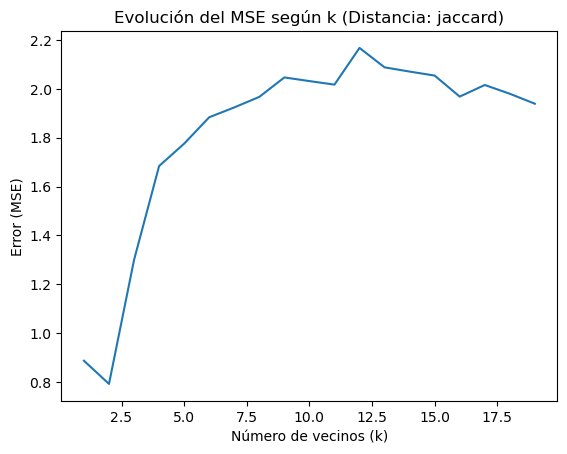


Evaluando con la distancia: chebyshev
Cuando usamos k= 1 obtenemos 0.8867187499999997
Cuando usamos k= 2 obtenemos 1.0998357092276616
Cuando usamos k= 3 obtenemos 0.911086418597434
Cuando usamos k= 4 obtenemos 0.8877619882121779
Cuando usamos k= 5 obtenemos 0.697081634694929
Cuando usamos k= 6 obtenemos 0.7335925451191097
Cuando usamos k= 7 obtenemos 0.939938018225269
Cuando usamos k= 8 obtenemos 0.99092184321872
Cuando usamos k= 9 obtenemos 0.9417305361981603
Cuando usamos k= 10 obtenemos 1.1146936644476155
Cuando usamos k= 11 obtenemos 1.1850348242946211
Cuando usamos k= 12 obtenemos 1.167060221475051
Cuando usamos k= 13 obtenemos 1.2051428010843885
Cuando usamos k= 14 obtenemos 1.1538511332946024
Cuando usamos k= 15 obtenemos 1.1973052137022049
Cuando usamos k= 16 obtenemos 1.1322335953423714
Cuando usamos k= 17 obtenemos 1.1878764547589777
Cuando usamos k= 18 obtenemos 1.203583468236109
Cuando usamos k= 19 obtenemos 1.1958133935186357
Mejor resultado obtenido con la distancia cheb

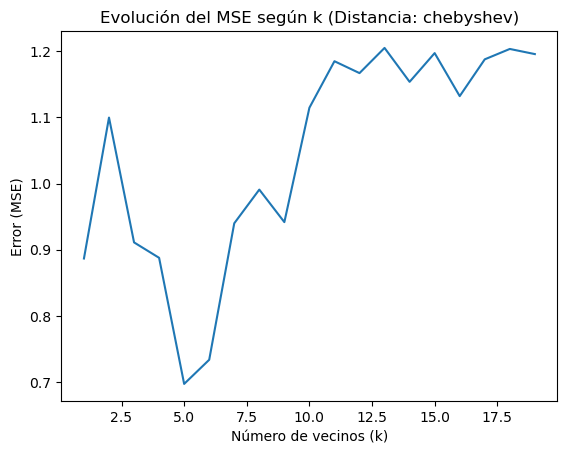


Evaluando con la distancia: minkowski
Cuando usamos k= 1 obtenemos 0.8867187499999997
Cuando usamos k= 2 obtenemos 0.5378715535016638
Cuando usamos k= 3 obtenemos 0.7794867506670169
Cuando usamos k= 4 obtenemos 0.7654578769328106
Cuando usamos k= 5 obtenemos 0.7775088363233305
Cuando usamos k= 6 obtenemos 0.8571355293527415
Cuando usamos k= 7 obtenemos 0.8498699201495299
Cuando usamos k= 8 obtenemos 0.8767299515004292
Cuando usamos k= 9 obtenemos 0.9956786699784331
Cuando usamos k= 10 obtenemos 1.0191098568364008
Cuando usamos k= 11 obtenemos 0.9958124970009256
Cuando usamos k= 12 obtenemos 1.0127201290880672
Cuando usamos k= 13 obtenemos 1.1869775026923686
Cuando usamos k= 14 obtenemos 1.2079226583329519
Cuando usamos k= 15 obtenemos 1.1834497016078998
Cuando usamos k= 16 obtenemos 1.2162130029854028
Cuando usamos k= 17 obtenemos 1.2253949888647608
Cuando usamos k= 18 obtenemos 1.2380187311526962
Cuando usamos k= 19 obtenemos 1.2101815555749085
Mejor resultado obtenido con la distanc

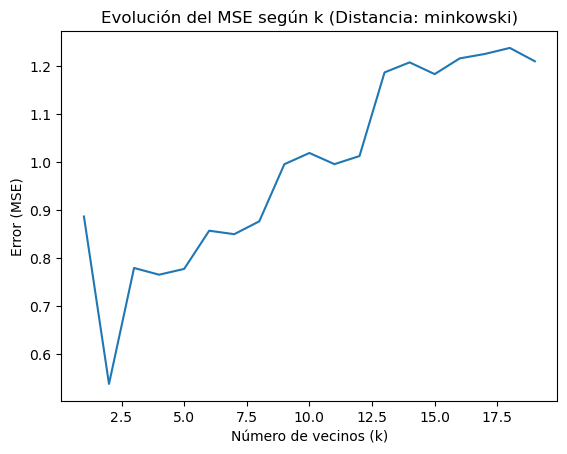

In [25]:
errores_por_distancia = evaluar_todas_las_distancias(usuario=usuario, lista_peliculas=lista_peliculas, valoraciones_peliculas=valoraciones_peliculas, min_vecinos=min_vecinos)

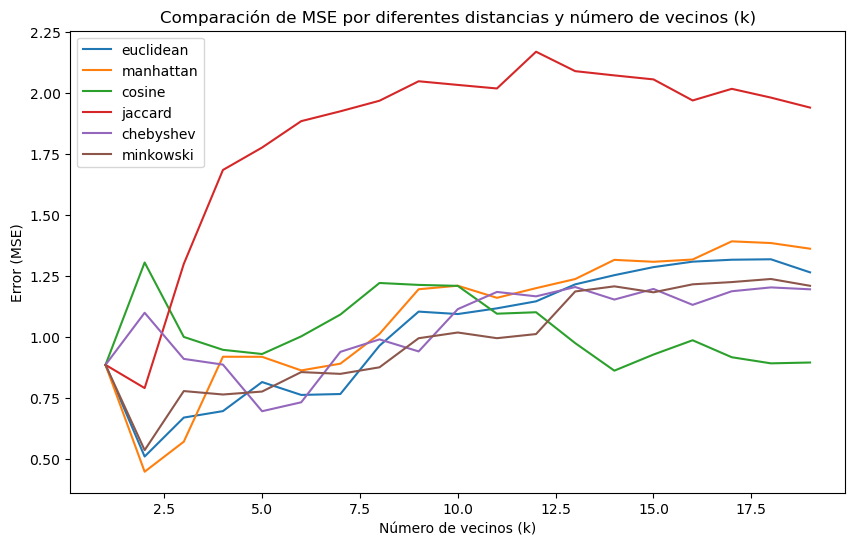

In [145]:
graficar_errores_por_distancia(errores_por_distancia=errores_por_distancia, min_vecinos=min_vecinos)

### Conclusión K vecinos:
**La mejor distancia:**

En términos de error más bajo con el menor k, la distancia Manhattan es la mejor opción con un MSE de 0.4495 en k=2. La distancia Euclidean también es una buena candidata con un MSE de 0.5117 en k=2, aunque es ligeramente superior a Manhattan.\
Si preferimos trabajar con un valor de k más alto, donde más vecinos participan en la recomendación, Cosine es la mejor opción con k=14 y un MSE de 0.8630. Esto indica que Cosine puede capturar relaciones más profundas entre los ítems con más vecinos.

**El valor de K:**\
Para las distancias Euclidean, Manhattan, Minkowski, y Jaccard, el mejor valor de k es 2, lo que sugiere que en estos casos un pequeño número de vecinos cercanos proporciona mejores predicciones.\
Cosine destaca por permitir un valor de k mayor (14), lo que implica que en este caso agregar más vecinos mejora la calidad de las predicciones.\
Chebyshev muestra un comportamiento óptimo con k=5, lo que lo coloca entre los extremos de tener pocos o muchos vecinos.

En resumidas cuentas, nos quedaremos en principio (ahora lo comprobaremos) con la distancia de manhattan con K=2, en caso de querer muchos vecinos utilizaría la de cosine

### Ejecutar el codigo de cada algoritmo para K=2

Puesto que ya hemos valorado la mejor K, no hace falta limitar el calculo de similitud a las primeras 50 peliculas

In [151]:
usuario = 3
mejores_vecinos = 2

# Obtener lista de películas y valoraciones
lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario, escasez)
lista_peliculas, valoraciones_peliculas = peliculas_con_minimo_vecinos(
    lista_peliculas_usuario=lista_peliculas, 
    valoraciones_peliculas=valoraciones_peliculas, 
    usuario_pelicula=usuario_pelicula, 
    vecinos_min=mejores_vecinos
)

# Similitud Euclidean
similitud_euclideana = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='euclidean', 
    vecinos=mejores_vecinos
)
print("Similitud Euclidean:", similitud_euclideana)

# Similitud Manhattan
similitud_manhattan = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='manhattan', 
    vecinos=mejores_vecinos
)
print("Similitud Manhattan:", similitud_manhattan)

# Similitud Cosine
similitud_cosine = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='cosine', 
    vecinos=mejores_vecinos
)
print("Similitud Cosine:", similitud_cosine)

# Similitud Jaccard
similitud_jaccard = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='jaccard', 
    vecinos=mejores_vecinos
)
print("Similitud Jaccard:", similitud_jaccard)

# Similitud Chebyshev
similitud_chebyshev = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='chebyshev', 
    vecinos=mejores_vecinos
)
print("Similitud Chebyshev:", similitud_chebyshev)

# Similitud Minkowski
similitud_minkowski = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='minkowski', 
    vecinos=mejores_vecinos,
    minkowski=True
)
print("Similitud Minkowski:", similitud_minkowski)


ID's de películas votadas por el usuario: [21, 32, 45, 47, 52, 58, 106, 125, 126, 162]... (total: 216)
Valoraciones de las películas votadas por el usuario: [3.0, 2.0, 3.0, 2.0, 3.0, 3.0, 4.0, 5.0, 1.0, 5.0]... (total: 216)
Similitud Euclidean: [2.0909090909090913, 0.9659090909090912, 1.875, 0.9659090909090912, 2.575, 2.575, 3.1315789473684212, 0.5, 4.696428571428571, 3.8350000000000004, 4.786585365853659, 0.5, 5.0, 0.5, 4.986413043478262, 1.4218750000000002, 3.6590909090909096, 4.548076923076923, 5.0, 0.5, 4.684948979591837, 4.403125, 4.125, 2.4192307692307695, 1.503289473684211, 3.8350000000000004, 2.8000000000000003, 0.5, 0.5, 0.798349056603774, 4.340909090909092, 4.6692307692307695, 5.0, 0.5, 4.705882352941177, 0.5, 0.5500000000000003, 3.2159090909090913, 5.0, 2.0909090909090913, 1.715909090909091, 5.0, 2.278409090909091, 3.7, 2.6785524920466597, 4.33, 2.9459459459459465, 5.0, 3.9296875000000004, 2.7179054054054057, 3.9659090909090917, 5.0, 4.5048076923076925, 5.0, 3.96590909090909

Ahora vamos a comparar cada una de las distancias con las valoraciones originales

In [30]:
def graficar_similitudes(valoraciones_peliculas, similitudes_dict, limit=25):
    plt.figure(figsize=(10, 6))

    # Graficar las valoraciones originales (limitadas a las primeras `limit` películas)
    plt.plot(valoraciones_peliculas[:limit], label="Valoraciones Originales", marker='o', linestyle='-', color='black')

    # Graficar las similitudes de cada distancia (limitadas a las primeras `limit` películas)
    for distancia, similitudes in similitudes_dict.items():
        plt.plot(similitudes[:limit], label=f"Similitud {distancia}", marker='o', linestyle='--')

    # Etiquetas del gráfico
    plt.xlabel('Películas')
    plt.ylabel('Valoración')
    plt.title(f'Similitudes por Distancia (Primeras {limit} Películas)')
    plt.legend()
    plt.show()

def calcular_mejor_distancia_global(valoraciones_peliculas, similitudes_dict):
    errores_totales = {}

    # Calcular el error total para cada distancia
    for distancia, similitudes in similitudes_dict.items():
        error_total = sum(abs(valoracion - similitudes[idx]) for idx, valoracion in enumerate(valoraciones_peliculas))
        errores_totales[distancia] = error_total

    # Seleccionar la distancia con el menor error total
    mejor_distancia_global = min(errores_totales, key=errores_totales.get)
    
    return mejor_distancia_global, errores_totales

def calcular_porcentaje_error(valoraciones_peliculas, similitudes_dict):
    errores_porcentaje = {}
    suma_valoraciones = sum(abs(valoracion) for valoracion in valoraciones_peliculas)  # Suma de las valoraciones originales

    # Calcular el porcentaje de error para cada distancia
    for distancia, similitudes in similitudes_dict.items():
        error_total = sum(abs(valoracion - similitudes[idx]) for idx, valoracion in enumerate(valoraciones_peliculas))
        # Calculamos el porcentaje de error en relación a la suma de las valoraciones
        porcentaje_error = (error_total / suma_valoraciones) * 100
        errores_porcentaje[distancia] = porcentaje_error

    # Seleccionar la distancia con el menor porcentaje de error
    mejor_distancia_global = min(errores_porcentaje, key=errores_porcentaje.get)
    
    # Comparar los porcentajes de error con la mejor distancia
    comparacion_errores = {}
    mejor_error = errores_porcentaje[mejor_distancia_global]
    
    for distancia, porcentaje_error in errores_porcentaje.items():
        comparacion_errores[distancia] = {
            "porcentaje_error": porcentaje_error,
            "comparado_con_mejor": (porcentaje_error / mejor_error) * 100
        }

    return mejor_distancia_global, comparacion_errores

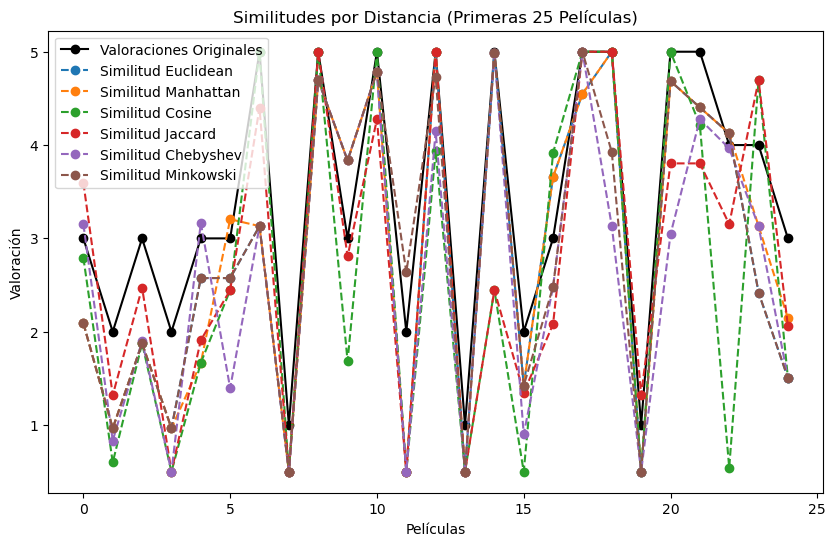

In [165]:
similitudes_dict = {
    "Euclidean": similitud_euclideana,
    "Manhattan": similitud_manhattan,
    "Cosine": similitud_cosine,
    "Jaccard": similitud_jaccard,
    "Chebyshev": similitud_chebyshev,
    "Minkowski": similitud_minkowski
}

# Graficar sin comparación
graficar_similitudes(valoraciones_peliculas, similitudes_dict,limit=25)

## 5. Validación

In [168]:
# Calcular el porcentaje de error y las comparaciones
mejor_distancia_global, comparacion_errores = calcular_porcentaje_error(valoraciones_peliculas, similitudes_dict)

# Mostrar el mejor resultado
print(f"La mejor distancia global es {mejor_distancia_global}")

# Mostrar los porcentajes de error y comparaciones
for distancia, datos in comparacion_errores.items():
    print(f"Distancia: {distancia}")
    print(f"  Porcentaje de error: {datos['porcentaje_error']:.2f}%")
    print(f"  Comparado con la mejor: {datos['comparado_con_mejor']:.2f}%\n")


La mejor distancia global es Manhattan
Distancia: Euclidean
  Porcentaje de error: 19.20%
  Comparado con la mejor: 106.22%

Distancia: Manhattan
  Porcentaje de error: 18.08%
  Comparado con la mejor: 100.00%

Distancia: Cosine
  Porcentaje de error: 20.25%
  Comparado con la mejor: 112.02%

Distancia: Jaccard
  Porcentaje de error: 21.69%
  Comparado con la mejor: 119.99%

Distancia: Chebyshev
  Porcentaje de error: 20.68%
  Comparado con la mejor: 114.38%

Distancia: Minkowski
  Porcentaje de error: 18.74%
  Comparado con la mejor: 103.65%



### `Con todos los calculos hechos, nos quedaremos con la distancia de Manhattan, da un error del 18.08%, es decir tiene un accuracy del 81.92%`

## 6. Predicción

Ahora que ya sabes que distancia y que K nos corresponde podemos hacer la prediccion para el usuario que deseemos, esta predicción nos devolverá las 10 mejores predicciones del usuario, las cuales se le recomendarían

In [41]:
import pandas as pd

# Cargar los archivos CSV proporcionados
movies = pd.read_csv('BBDD_100K/movies.csv')
ratings = pd.read_csv('BBDD_100K/ratings.csv')

# Mostrar una muestra de los datos para asegurarnos de que se han cargado correctamente
print(movies.head())
print(ratings.head())


   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [53]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor

def peliculas_no_valoradas(usuario, matriz_escasez):
    # Obtener todas las películas
    todas_las_peliculas = matriz_escasez.columns.tolist()
    # Filtrar las películas que el usuario no ha valorado (NaN en la matriz de escasez)
    peliculas_no_votadas = matriz_escasez.loc[usuario][matriz_escasez.loc[usuario].isna()].index.tolist()
    
    return peliculas_no_votadas

def peliculas_con_minimo_vecinos(lista_peliculas_usuario, usuario_pelicula, vecinos_min):
    # Filtramos solo las películas con al menos 'vecinos_min' valoraciones distintas de 0
    peliculas_filtradas = []

    for pelicula in lista_peliculas_usuario:
        # Asegurarse de que 'pelicula' es el identificador correcto que corresponde a las columnas de usuario_pelicula
        if pelicula not in usuario_pelicula.columns:
            continue
        
        # Seleccionamos los usuarios que vieron la película, es decir, aquellos con valoraciones != 0
        usuarios_que_vieron_la_pelicula = usuario_pelicula[usuario_pelicula[pelicula].notna() & (usuario_pelicula[pelicula] != 0)][pelicula]
        
        # Si el número de usuarios que vieron la película es mayor o igual a 'vecinos_min', la añadimos a la lista
        if len(usuarios_que_vieron_la_pelicula) >= vecinos_min:
            peliculas_filtradas.append(pelicula)

    return peliculas_filtradas

def reescalar_prediccion(prediccion, min_rating=0.5, max_rating=5.0):
    # Escalar la predicción a un rango deseado (por ejemplo, entre 0.5 y 5.0)
    prediccion_reescalada = ((prediccion + 1) / 2) * (max_rating - min_rating) + min_rating
    # Asegurarse de que la predicción quede dentro del rango [min_rating, max_rating]
    return np.clip(prediccion_reescalada, min_rating, max_rating)

def recomendar_peliculas(usuario, escasez, usuario_pelicula, movies, distancia_escogida='manhattan', vecinos=2, top_n=10, limite_peliculas_no_votadas=100):
    # Obtener las películas que el usuario no ha valorado
    peliculas_no_votadas = peliculas_no_valoradas(usuario, escasez)
    
    # Limitar el número de películas no votadas que vamos a evaluar
    if len(peliculas_no_votadas) > limite_peliculas_no_votadas:
        peliculas_no_votadas = np.random.choice(peliculas_no_votadas, limite_peliculas_no_votadas, replace=False)
    
    # Filtrar las películas con al menos 'vecinos_min' valoraciones distintas de 0
    peliculas_no_votadas = peliculas_con_minimo_vecinos(peliculas_no_votadas, usuario_pelicula, vecinos_min=vecinos)
    
    # Predecir las valoraciones para las películas no votadas
    predicciones = []
    for pelicula in peliculas_no_votadas:
        # Seleccionamos los usuarios que han valorado la película
        usuarios_que_vieron_la_pelicula = usuario_pelicula[usuario_pelicula[pelicula].notna() & (usuario_pelicula[pelicula] != 0)]
        
        if usuarios_que_vieron_la_pelicula.empty:
            continue  # Saltar si no hay usuarios con valoraciones para esta película
        
        # Datos del usuario objetivo para la predicción
        usuario_objetivo = usuario_pelicula.iloc[[usuario]]

        # Reemplazar NaNs con ceros en los datos de entrada para evitar errores
        usuarios_que_vieron_la_pelicula = usuarios_que_vieron_la_pelicula.fillna(0)
        usuario_objetivo = usuario_objetivo.fillna(0)

        # Modelo KNN para la predicción
        knn = KNeighborsRegressor(metric=distancia_escogida, n_neighbors=vecinos)
        knn.fit(usuarios_que_vieron_la_pelicula, usuario_pelicula.loc[usuarios_que_vieron_la_pelicula.index, pelicula])
        
        # Predecir la valoración del usuario para la película
        prediccion_usuario = knn.predict(usuario_objetivo)[0]
        prediccion_reescalada = reescalar_prediccion(prediccion_usuario)
        
        # Guardar la predicción con el ID de la película
        predicciones.append((pelicula, prediccion_reescalada))
    
    # Ordenar las predicciones por valoración en orden descendente
    predicciones.sort(key=lambda x: x[1], reverse=True)
    
    # Seleccionar las top_n mejores películas
    mejores_peliculas = predicciones[:top_n]
    
    # Obtener los nombres de las mejores películas
    recomendaciones = pd.DataFrame(mejores_peliculas, columns=['movieId', 'Predicted Rating']).merge(movies, on='movieId')
    
    return recomendaciones[['title', 'Predicted Rating', 'genres']]

# Ejemplo de ejecución para el usuario 3
usuario_id = 3
recomendaciones = recomendar_peliculas(usuario_id, escasez, usuario_pelicula, movies, distancia_escogida='manhattan', vecinos=2, top_n=10)

recomendaciones.head(10)


,title,Predicted Rating,genres
0,"Conformist, The (Conformista, Il) (1970)",5.000000,Drama
1,Louis C.K.: Live at The Comedy Store (2015),5.000000,Comedy
2,Where Eagles Dare (1968),4.661659,Action|Adventure|War
3,"Fantastic Fear of Everything, A (2012)",4.639613,Comedy
4,"Very Potter Musical, A (2009)",4.607908,Comedy|Musical
5,United 93 (2006),4.476428,Crime|Drama
6,Still Alice (2014),4.138839,Drama
7,Ulee's Gold (1997),4.045770,Drama
8,Jonestown: The Life and Death of Peoples Templ...,4.028548,Documentary
9,Why Don't You Play In Hell? (Jigoku de naze wa...,3.937405,Action|Drama


También podemos ver que usuario es el que mas se parece a otro usuario

In [60]:
usuario_id = 3
def usuario_mas_similar(usuario_id, escasez, min_peliculas_comunes=5):
    # Extraer las valoraciones del usuario objetivo
    valoraciones_usuario = escasez.loc[usuario_id]
    
    # Calcular la correlación de Pearson entre el usuario objetivo y todos los demás usuarios
    correlaciones = escasez.corrwith(valoraciones_usuario, axis=1, method='pearson')
    
    # Eliminar la correlación del usuario consigo mismo
    correlaciones = correlaciones.drop(index=usuario_id)
    
    # Filtrar usuarios con pocas valoraciones en común
    peliculas_comunes = escasez.notna().multiply(valoraciones_usuario.notna(), axis=0).sum(axis=1)
    correlaciones = correlaciones[peliculas_comunes >= min_peliculas_comunes]
    
    # Eliminar usuarios con una correlación de 1 (idénticas valoraciones)
    correlaciones = correlaciones[correlaciones < 1]
    
    # Encontrar el usuario con la mayor correlación positiva
    usuario_mas_similar = correlaciones.idxmax()
    coeficiente_correlacion = correlaciones.max()
    
    return usuario_mas_similar, coeficiente_correlacion

# Ejemplo de uso
usuario_similar, correlacion = usuario_mas_similar(usuario_id, escasez)
print(f"El usuario más similar al usuario {usuario_id} es {usuario_similar} con un coeficiente de correlación de Pearson de {correlacion:.2f}.")



El usuario más similar al usuario 3 es 527 con un coeficiente de correlación de Pearson de 0.68.
